In [1]:
# SFR = Stellar Formation Rate

# File: SFR.py
# Date: 2025-02-20 (actualizado 2025-07-15)

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # Importar LogNorm



In [2]:
# Archivo fits
fits_file = "ngc6946Ha_I_Ha_ksb2004.fits"  
hdul = fits.open(fits_file)
data = hdul[0].data
hdul.close()

In [3]:
# Suma total de H_alpha
total_Ha_flux = np.sum(data)

#print(total_Ha_flux)

# Máximo
max_Ha_flux = np.max(data)

# SFR esperado
SFR_total = 500  # Msun/yr

# Factor de conversión
scaling_factor = SFR_total / total_Ha_flux

# Aplicar el reescalamiento lineal
SFR_map = data * scaling_factor

# Aplicar logarítmica 
SFR_map_log = np.log10(1 + SFR_map)  

# Verificar que la suma total sigue siendo 500 Msun/yr
SFR_check = np.sum(SFR_map)
#print(f"Suma total de SFR: {SFR_check:.2f} Msun/yr")

In [4]:
print(SFR_map_log.min(), SFR_map_log.max())
print(f"Factor de escalamiento: {scaling_factor}")
print(f"Verificación SFR total: {SFR_check} Msun/yr")

-3.7173842e-05 0.05780769
Factor de escalamiento: 0.006822320757379939
Verificación SFR total: 500.0002746582031 Msun/yr


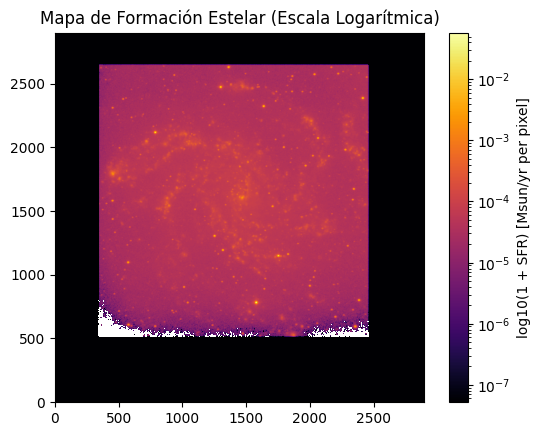

In [5]:
# Mostrar imagen con LogNorm
plt.imshow(SFR_map_log, origin="lower", cmap="inferno", norm=LogNorm())
plt.colorbar(label="log10(1 + SFR) [Msun/yr per pixel]")
plt.title("Mapa de Formación Estelar (Escala Logarítmica)")
plt.show()

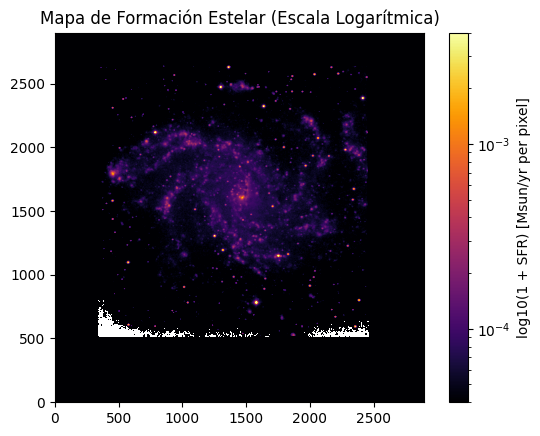

In [6]:
#imagen modificada
plt.imshow(SFR_map_log, origin="lower", cmap="inferno", norm=LogNorm(vmin=4e-5 , vmax=4e-3))
plt.colorbar(label="log10(1 + SFR) [Msun/yr per pixel]")
plt.title("Mapa de Formación Estelar (Escala Logarítmica)")
plt.show()
